In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# maf=1e-3
# n = !wc -l $eur_samples_path
# n_eur = int(n[0].split(' ')[0])
# mac = maf*(2*n_eur)

mac = 20

config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
…,…,…,…,…
"""regulatory_nondir""","""max_fz_blood""","""pink""","""Flashzoi abs max across blood""",1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1


In [3]:
fzdf = (
    pl.read_parquet('/home/dnanexus/data_dir/flashzoi_proximal_variants_gencode40_avg_score.parquet')
    .with_columns(
        fz_blood = (pl.col('RNA:blood_7531') + pl.col('RNA:blood_7532') + pl.col('RNA:blood_7533'))/3
    )
    .with_columns(
        max_fz_blood = pl.col('fz_blood').abs()
    )
    .select(['id', 'region', 'fz_blood', 'max_fz_blood'])
)
fzdf.head()#.collect()

id,region,fz_blood,max_fz_blood
str,str,f32,f32
"""chr1:3652123:G:A""","""ENSG00000078900""",0.077435,0.077435
"""chr1:3652442:G:T""","""ENSG00000078900""",-0.05002,0.05002
"""chr1:3652966:G:T""","""ENSG00000078900""",0.001191,0.001191
"""chr1:3652415:C:G""","""ENSG00000078900""",0.430102,0.430102
"""chr1:3652543:C:G""","""ENSG00000078900""",0.029333,0.029333


In [4]:
# anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130.parquet")
anno = pl.read_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_251130_fillna.parquet")



variant_class = "missense"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# Filter variant classes
min_range = -500
max_range = +500

abs_phenotypes = False
extreme_pheno_dir = 'Bottom'

anno = (
    anno
    .join(
        fzdf,
        on=['id', 'region'],
        how='left'
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# anno.collect()
anno_wide = (
    anno
    .filter(
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # filter_expression &

        # Proximity to TSS
        (pl.col('dist_to_tss') >= min_range) &
        (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    # .collect(engine='streaming')
    # .drop_nulls()
    # .filter(pl.col('gene_name').is_in(['LDLR', 'APOB']))
)

anno_wide

tss,absplice2_max,gene_name,abexp_min,pangolin_score,esmscoremissense,fz_blood,loftee_hc,dist_to_tss,delta_score,cadd_raw,absplice_dna_max,promoterai,region,gene_length,am_pathogenicity,strand,promoterai_abs,score_pai3d,gpn_star_llr_calibrated_mean,max_fz_blood,id,abexp_abs_max
i64,f32,str,f32,f32,f32,f32,i8,i64,f32,f32,f32,f32,str,i64,f32,str,f32,f32,f32,f32,str,f32
132946874,0.0,"""TSC1""",0.002469,0.0,0.0,0.00001,0,-362,0.0,0.264581,0.0,-0.001,"""ENSG00000165699""",55528,0.0,"""-1""",0.001,0.0,-0.250039,0.00001,"""chr9:132947236:C:A""",0.003431
72031901,0.000037,"""NPFFR2""",0.0,0.01,0.0,0.005384,0,290,0.0,-0.049725,0.001,0.0299,"""ENSG00000056291""",116405,0.0,"""1""",0.0299,0.227093,0.176318,0.005384,"""chr4:72032191:G:T""",0.0
3314402,0.000034,"""NFIC""",0.002469,0.02,0.0,0.000551,0,211,0.0,0.377255,0.0,-0.151,"""ENSG00000141905""",154816,0.0,"""1""",0.151,0.0,-1.836838,0.000551,"""chr19:3314613:C:T""",0.003431
131470831,0.000033,"""ARG1""",-0.019552,0.0,0.0,0.000248,0,423,0.0,-0.280035,0.0,0.012,"""ENSG00000118520""",113502,0.0,"""1""",0.012,0.0,-0.061321,0.000248,"""chr6:131471254:A:T""",0.019552
72031901,0.007637,"""NPFFR2""",0.0,0.78,0.0,-0.77185,0,300,0.0,4.437355,0.007,-0.3252,"""ENSG00000056291""",116405,0.0,"""1""",0.3252,0.0,-4.092851,0.77185,"""chr4:72032201:G:A""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
40694773,0.000314,"""RAD51""",-0.019984,0.03,0.0,0.011993,0,38,0.0,0.029534,0.003,0.1015,"""ENSG00000051180""",37568,0.0,"""1""",0.1015,0.0,-1.34713,0.011993,"""chr15:40694811:C:T""",0.019984
227164453,0.000166,"""COL4A4""",-0.076826,0.0,0.0,0.020078,0,27,0.0,1.549478,0.004,0.0132,"""ENSG00000081052""",161741,0.0,"""-1""",0.0132,0.0,-1.59712,0.020078,"""chr2:227164426:G:A""",0.076826
227164453,0.0,"""COL4A4""",-0.019552,0.0,0.0,0.023014,0,-288,0.0,0.015522,0.0,0.0626,"""ENSG00000081052""",161741,0.0,"""-1""",0.0626,0.0,0.060471,0.023014,"""chr2:227164741:C:A""",0.019552


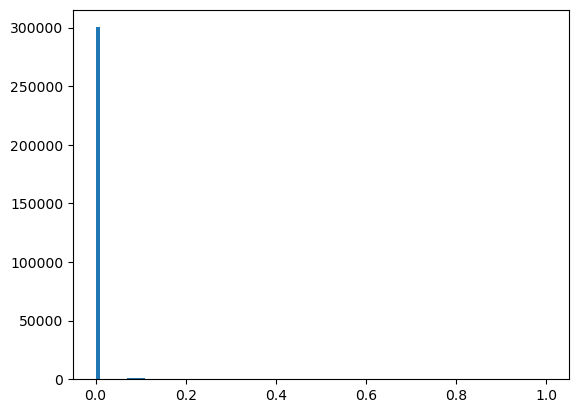

In [5]:
plt.hist(anno_wide['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [6]:
selected_annos = anno_config_df.filter(
    # (pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation', 'splicing'])) # CDS
    # pl.col('category').is_in(['missense', 'genetic_diversity', 'conservation']) # missense
    # pl.col('category').is_in(['genetic_diversity', 'conservation', 'splicing']) # 'splicing'
    
    (pl.col('category').is_in(['regulatory', 'genetic_diversity', 'conservation'])) # regulation
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'regulatory_nondir'])) # non coding
    # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation'])) # introns
)['annotation'].to_list()

melted_anno = (
    anno_wide

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null())
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_generank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["annotation"]).cast(pl.Float32),
        anno_score_genecount = pl.len().over(["region", "annotation"]).cast(pl.Int32),
        anno_score_count = pl.len().over(["annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_geneptile = pl.col('annotation_score_dircor_generank') / pl.col('anno_score_genecount').round(4).cast(pl.Float32),
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_genecount', 'anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_generank,annotation_score_dircor_rank,annotation_score_dircor_geneptile,annotation_score_dircor_ptile
str,str,str,f32,str,i8,f32,f32,f32,f32
"""chr9:132947236:C:A""","""ENSG00000165699""","""cadd_raw""",0.264581,"""genetic_diversity""",-1,232.0,237021.0,0.627027,0.759393
"""chr4:72032191:G:T""","""ENSG00000056291""","""cadd_raw""",-0.049725,"""genetic_diversity""",-1,342.0,281344.0,0.834146,0.9014
"""chr19:3314613:C:T""","""ENSG00000141905""","""cadd_raw""",0.377255,"""genetic_diversity""",-1,161.0,214497.0,0.462644,0.687228
"""chr6:131471254:A:T""","""ENSG00000118520""","""cadd_raw""",-0.280035,"""genetic_diversity""",-1,342.0,297268.0,0.9,0.952419
"""chr4:72032201:G:A""","""ENSG00000056291""","""cadd_raw""",4.437355,"""genetic_diversity""",-1,1.0,3394.0,0.002439,0.010874
…,…,…,…,…,…,…,…,…,…
"""chr15:40694811:C:T""","""ENSG00000051180""","""abexp_min""",-0.019984,"""regulatory""",1,312.0,90828.5,0.527027,0.291006
"""chr2:227164426:G:A""","""ENSG00000081052""","""abexp_min""",-0.076826,"""regulatory""",1,55.5,22629.0,0.105513,0.072501
"""chr2:227164741:C:A""","""ENSG00000081052""","""abexp_min""",-0.019552,"""regulatory""",1,298.0,101510.0,0.56654,0.325229


In [ ]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_geneptile'])
    .agg(
        n_vars_at_geneptile = pl.len()
    )
    .sort('annotation_score_dircor_geneptile', descending=True)
    .with_columns(
        n_vars_above_geneptile = pl.col('n_vars_at_geneptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_geneptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_generank,annotation_score_dircor_rank,annotation_score_dircor_geneptile,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,i8,f32,f32,f32,f32,u64,u64
"""chr9:132947236:C:A""","""ENSG00000165699""","""cadd_raw""",0.264581,"""genetic_diversity""",-1,232.0,237021.0,0.627027,0.759393,1,75099
"""chr4:72032191:G:T""","""ENSG00000056291""","""cadd_raw""",-0.049725,"""genetic_diversity""",-1,342.0,281344.0,0.834146,0.9014,1,30776
"""chr19:3314613:C:T""","""ENSG00000141905""","""cadd_raw""",0.377255,"""genetic_diversity""",-1,161.0,214497.0,0.462644,0.687228,1,97623
"""chr6:131471254:A:T""","""ENSG00000118520""","""cadd_raw""",-0.280035,"""genetic_diversity""",-1,342.0,297268.0,0.9,0.952419,1,14852
"""chr4:72032201:G:A""","""ENSG00000056291""","""cadd_raw""",4.437355,"""genetic_diversity""",-1,1.0,3394.0,0.002439,0.010874,1,308726
…,…,…,…,…,…,…,…,…,…,…,…
"""chr15:40694811:C:T""","""ENSG00000051180""","""abexp_min""",-0.019984,"""regulatory""",1,312.0,90828.5,0.527027,0.291006,20,221301
"""chr2:227164426:G:A""","""ENSG00000081052""","""abexp_min""",-0.076826,"""regulatory""",1,55.5,22629.0,0.105513,0.072501,15,289498
"""chr2:227164741:C:A""","""ENSG00000081052""","""abexp_min""",-0.019552,"""regulatory""",1,298.0,101510.0,0.56654,0.325229,12171,216695


In [ ]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_geneptile').max(),
).sort('n_vars', descending=True)

# ct_df['max_ptile'].min()

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""gpn_star_llr_calibrated_mean""",312119,1.0
"""abexp_min""",312119,0.999998
"""cadd_raw""",312119,1.0
"""promoterai""",312119,1.0
"""fz_blood""",311614,1.0


## Odds ratio computation

In [10]:
n_steps = 101
min_rank_cutoff = 100
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno_wide.shape[0]])
or_threshold_pheno = 0.99

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
108
117
127
137
…
226228
245183
265725


In [ ]:
# Read Olink RVAT significant
olnk_subset = pl.read_csv('/home/dnanexus/data_dir/olink/olink_genebass1e6_371genes.tsv', separator='\t')
olnk_rvat_genes = (
    pl.read_csv('/home/dnanexus/data_dir/olink/olink_rvat_fdr.tsv', separator='\t')
    .filter(pl.col('is_plof_significant_fdr')==True)
    # .filter(pl.col('n_pos')>=10)
    .filter(pl.col('gene').is_in(olnk_subset['region']))['gene'].to_list()
)
olnk_rvat_genes = [g+'_olink' for g in olnk_rvat_genes]


# Read Olink phenotype data
olink_appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_371olink_rint_corrected90pcs_EUR.parquet")

# Merge phenotype data and annotation data
gp_corr_df = (
    olink_appv
    .filter(
        (pl.col('phenotype').is_in(olnk_rvat_genes)) &
        (pl.col('n_individuals') <= mac)
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
        .then(pl.col('mean_pheno_value').abs())
        .otherwise(pl.col('mean_pheno_value'))
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        mean_pheno_value_rank=pl.col('mean_pheno_value')
            .rank(method="average")
            .cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile=(
            pl.col('mean_pheno_value_rank') / pl.len()
        ).cast(pl.Float32)
    )
    .with_columns(
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
    .rename({
        'phenotype': 'olink_prot',
    })
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_corr_df
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "olink_prot", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_geneptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_geneptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_geneptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_geneptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

/tmp/ipykernel_276439/2029000632.py:7: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


Executing with odds ratios...


annotation,region,olink_prot,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,i64,u64,u64,u64,u64,f64
"""promoterai""","""ENSG00000164010""","""ENSG00000164010_olink""",312119,2,98,0,0,NaN
"""promoterai""","""ENSG00000151414""","""ENSG00000151414_olink""",312119,0,104,0,0,NaN
"""promoterai""","""ENSG00000117724""","""ENSG00000117724_olink""",312119,1,76,0,0,NaN
"""fz_blood""","""ENSG00000162998""","""ENSG00000162998_olink""",312119,3,79,0,0,NaN
"""promoterai""","""ENSG00000163295""","""ENSG00000163295_olink""",312119,0,82,0,0,NaN
…,…,…,…,…,…,…,…,…
"""fz_blood""","""ENSG00000120053""","""ENSG00000120053_olink""",100,0,0,0,81,NaN
"""cadd_raw""","""ENSG00000111252""","""ENSG00000111252_olink""",100,0,0,0,118,NaN
"""cadd_raw""","""ENSG00000108561""","""ENSG00000108561_olink""",100,0,0,1,52,NaN


## Plotting

In [12]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""fz_blood""",3.642267,4388,-3.642267,66,0.0,2.296068,1.134398,4.519489,0.072647,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.677242,4756,-3.677242,68,0.0,2.228536,1.101805,4.388073,0.069,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.712144,5154,-3.712144,72,0.0,2.104729,1.041925,4.146901,0.062556,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.747101,5586,-3.747101,74,0.0,1.696622,0.829443,3.322329,0.070914,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.782042,6054,-3.782042,77,0.0,1.570779,0.775116,3.090006,0.051553,"""crimson""","""Flashzoi Blood""","""regulatory"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""gpn_star_llr_calibrated_mean""",5.459376,287989,-5.459376,34,0.0,0.057782,0.025072,0.106922,0.008641,"""#942c80""","""GPN-Star""","""conservation"""
"""abexp_min""",5.459376,287989,-5.459376,33,0.044118,0.085111,0.025737,0.135555,0.034667,"""#80CBC4""","""AbExp min""","""regulatory"""
"""cadd_raw""",5.459376,287989,-5.459376,39,0.017241,0.042291,0.009048,0.060025,0.024558,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""


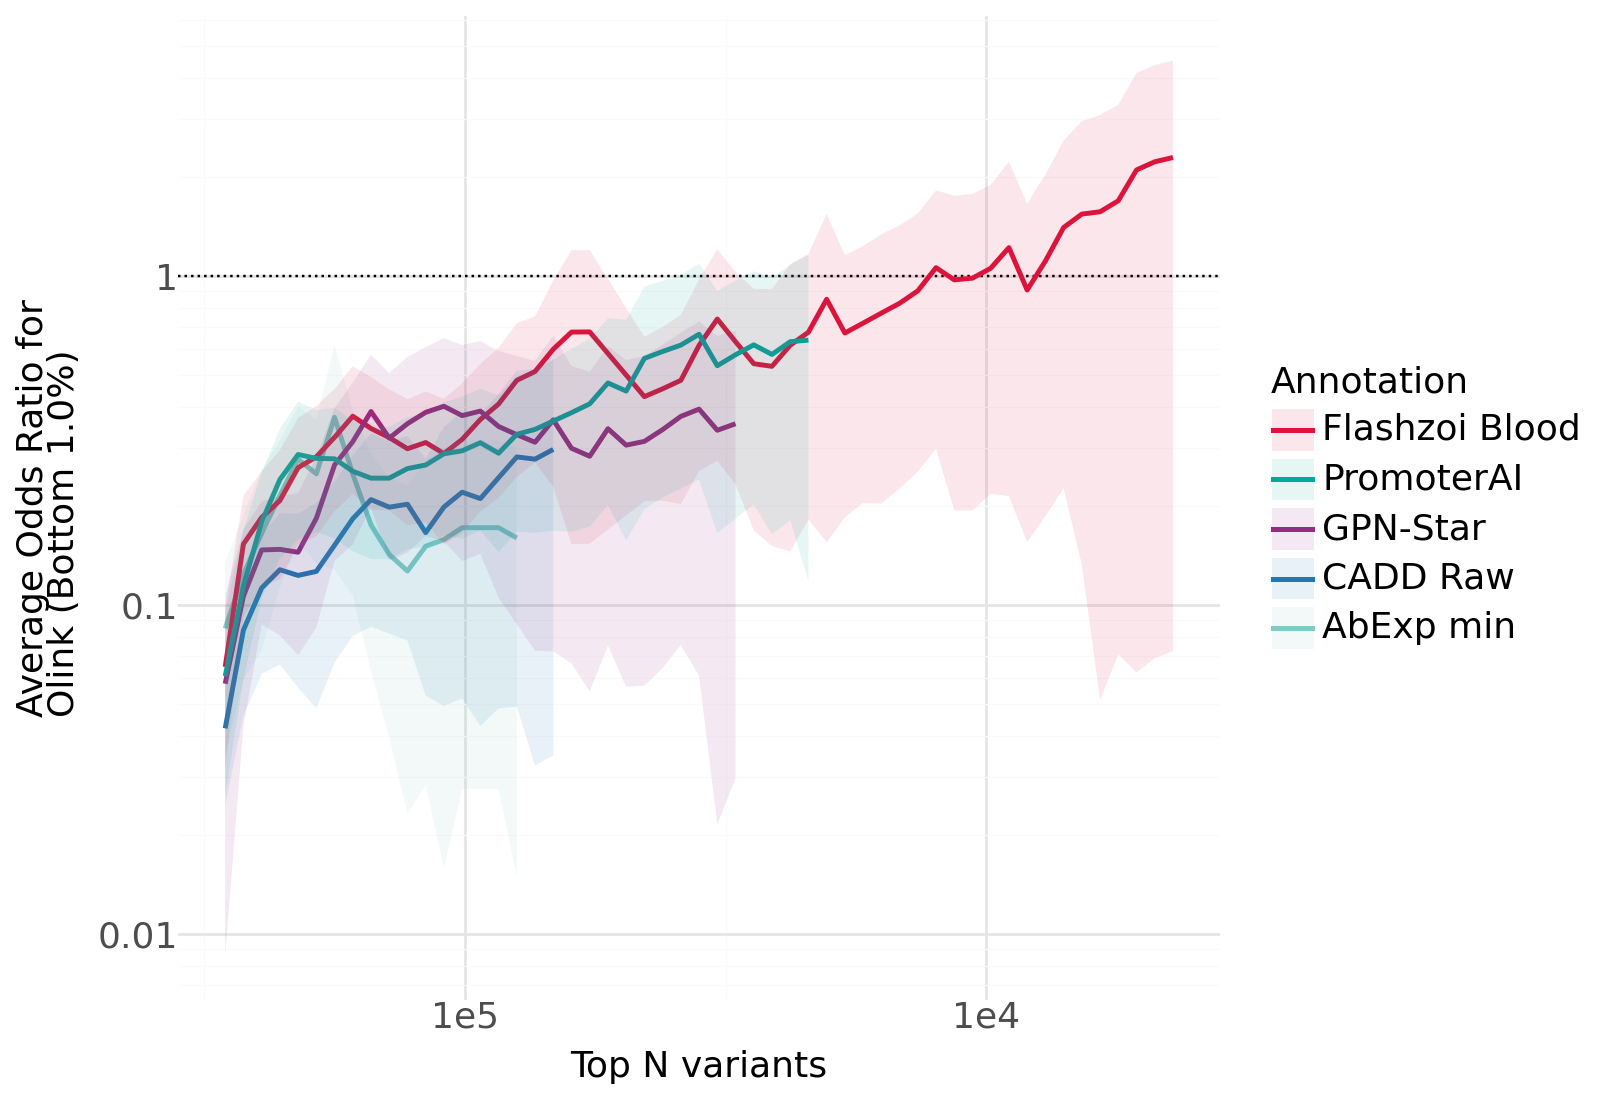

In [13]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -3.5) &
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_star_llr_calibrated_mean', 'cadd_raw', 'delta_score']))
        (pl.col('category').is_in(['regulatory', 'genetic_diversity', 'conservation']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

# Determine legend order based on final average odds ratio
legend_order = (
    plot_df.sort("log_rank_cutoff_inv")
    .group_by("label", maintain_order=True)
    .last()
    .sort("avg_odds_ratio", descending=True)
    ['label']
    .to_list()
)

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict, limits=legend_order)
    + scale_color_manual(values=color_dict, limits=legend_order)
    + labs(
        y=f"Average Odds Ratio for\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)

In [14]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""fz_blood""",3.642267,4388,-3.642267,66,0.0,2.296068,1.134398,4.519489,0.072647,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.677242,4756,-3.677242,68,0.0,2.228536,1.101805,4.388073,0.069,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.712144,5154,-3.712144,72,0.0,2.104729,1.041925,4.146901,0.062556,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.747101,5586,-3.747101,74,0.0,1.696622,0.829443,3.322329,0.070914,"""crimson""","""Flashzoi Blood""","""regulatory"""
"""fz_blood""",3.782042,6054,-3.782042,77,0.0,1.570779,0.775116,3.090006,0.051553,"""crimson""","""Flashzoi Blood""","""regulatory"""
